In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as pc
from pyproj import Proj, Transformer
import cartopy.crs as ccrs
import pandas as pd
import sys
import glob
import dask
import dask.distributed

### Dask Cluster

In [ ]:
n_workers = 6 #this number should be the same (or smaller) than the CPUs you have access to
n_threads = 2
processes = True
cluster = dask.distributed.LocalCluster(n_workers=n_workers,
                                                threads_per_worker=n_threads,
                                                processes=processes,
                                                local_directory='users/nathstep/',
                                                lifetime='4 hour',
                                                lifetime_stagger='10 minutes',
                                                lifetime_restart=True,
                                               dashboard_address=None,
                                                worker_dashboard_address=None)
client  = dask.distributed.Client(cluster)

In [3]:
client

NameError: name 'client' is not defined

In [ ]:
client.close()
cluster.close()

### Code

In [ ]:
work_dir = '/scratch/project_2010671/DMI-HAMOWIOWF_temp/HornsRev/'
output_dir = '/scratch/project_2010671/DMI-HAMOWIOWF_temp/HornsRev/'

##### Day averages

In [7]:
month = '202602'
for j in range(1,29)  :
    fileWF = sorted(glob.glob(work_dir + 'withOWF/crop' + month + str(j).zfill(2) + '*.nc'))
    #print(fileWF)
    hAVG_WF = xr.open_mfdataset(fileWF, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})
    
    filenoWF = sorted(glob.glob(work_dir + 'withoutOWF/crop' + month + str(j).zfill(2) + '*.nc'))
    #print(filenoWF)
    hAVG_noWF = xr.open_mfdataset(filenoWF, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})

    hAVG_WF['10ws'] = hAVG_WF['10ws']/hAVG_noWF['10ws'] - 1. # Velocity deficit normalized on the model without wind farms
    hAVG_WF['ws'] = hAVG_WF['ws']/hAVG_noWF['ws'] - 1.
        
    print((np.isnan(hAVG_WF['ws'].values)).any() == True) # Check for nan values
    
    hAVG = hAVG_WF.mean(dim='time')
    hAVG = hAVG.drop_vars(['10u','10v','100u','100v'])
    
    hAVG.to_netcdf(output_dir + 'withOWF/DayAVG_' + month + str(j).zfill(2) + '.nc', engine='netcdf4')
    print(f"{j}/31")

False
1/31


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/scratch/project_20

False
2/31


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/scratch/project_20

False
3/31


...

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/scratch/project_20

False
27/31


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/scratch/project_20

False
28/31


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/scratch/project_20

##### Month averages

In [6]:
month='202512'
filelist = sorted(glob.glob(output_dir + 'withOWF/DayAVG_' + month + '*.nc'))
hAVG = xr.open_mfdataset(filelist, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})
hAVG = hAVG.mean(dim='time')
hAVG.to_netcdf(output_dir + 'withOWF/MonthAVG_' + month + '.nc', engine='netcdf4')
print("Done")

Done


##### Total average

In [7]:
filelist = sorted(glob.glob(ouput_dir + 'withOWF/MonthAVG_*.nc'))
hAVG = xr.open_mfdataset(filelist, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})
print((np.isnan(hAVG['ws'].values)).any() == True) # Check for nan values
hAVG = hAVG.mean(dim='time')
hAVG.to_netcdf(output_dir + 'withOWF/TotalAVG.nc', engine='netcdf4')
print("Done")

False
Done


##### Day averages (PyWake)

In [11]:
month = '202512'
for j in range(1, 32)  :
    filelist = sorted(glob.glob(work_dir + 'PyWake/DMI_reg_area_' + month + str(j).zfill(2) + '*.nc'))
    filenoWF = sorted(glob.glob(work_dir + 'withoutOWF/crop' + month + str(j).zfill(2) + '*.nc'))
    
    pAVG = xr.open_mfdataset(filelist, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})
    hAVG = xr.open_mfdataset(filenoWF, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})
    
    pAVG['10ws'] = pAVG['10ws']/hAVG['10ws'] - 1. # Velocity deficit normalized on the model without wind farms
    pAVG['ws'] = pAVG['ws']/hAVG['ws'] - 1.
    
    print((np.isnan(pAVG['ws'].values)).any() == True) # Check for nan values
    
    pAVG = pAVG.mean(dim='time')
    pAVG = pAVG.drop_vars(['10u','10v','100u','100v'])
    
    pAVG.to_netcdf(output_dir + 'PyWake/pyDayAVG_' + month + str(j).zfill(2) + '.nc', engine='netcdf4')
    print(f"{j}/31")

False
1/31
False
2/31
False
3/31
False
4/31
False
5/31
False
6/31
False
7/31
False
8/31
False
9/31
False
10/31
False
11/31
False
12/31
False
13/31
False
14/31
False
15/31
False
16/31
False
17/31
False
18/31
False
19/31
False
20/31
False
21/31
False
22/31
False
23/31
False
24/31
False
25/31
False
26/31
False
27/31
False
28/31
False
29/31
False
30/31
False
31/31


##### Month averages (PyWake)

In [21]:
month = '202512'
filelist = sorted(glob.glob(output_dir + 'PyWake/pyDayAVG_' + month + '*.nc'))
pAVG = xr.open_mfdataset(filelist, combine='nested', concat_dim='time', parallel=False, chunks={'time':3}, coords='minimal')
pAVG = pAVG.mean(dim='time')

pAVG.to_netcdf(output_dir + 'PyWake/pyMonthAVG_' + month + '.nc', engine='netcdf4')
print('Done')

Done


##### Total average (PyWake)

In [23]:
filelist = sorted(glob.glob(output_dir + 'PyWake/pyMonthAVG_*.nc'))
pAVG = xr.open_mfdataset(filelist, combine='nested', concat_dim='time', parallel=False, chunks={'time':3})
print((np.isnan(pAVG['ws'].values)).any() == True) # Check for nan values
pAVG = pAVG.mean(dim='time')
pAVG.to_netcdf(output_dir + 'PyWake/pyTotalAVG.nc', engine='netcdf4')
print("Done")

False
Done


### Plotting

In [25]:
"""
CSV WIND TURBINES
"""
fname = work_dir + 'turbines_offshore.csv'
wt_dict = pd.read_csv(fname, header=0, index_col=False, usecols=[0, 1], dtype={'longitude':np.float64, 'latitude':np.float64})
#print(wt_dict)
wt = wt_dict.to_numpy()
#print(wt)

In [36]:
h_noWF = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/KriegersFlak/withoutOWF/MonthAVG_202604_detail.nc')

h_WF = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/KriegersFlak/withOWF/MonthAVG_202604_detail.nc')

py = xr.open_dataset('/scratch/project_2010671/DMI-HAMOWIOWF_temp/KriegersFlak/PyWake/pyMonthAVG_202604.nc')

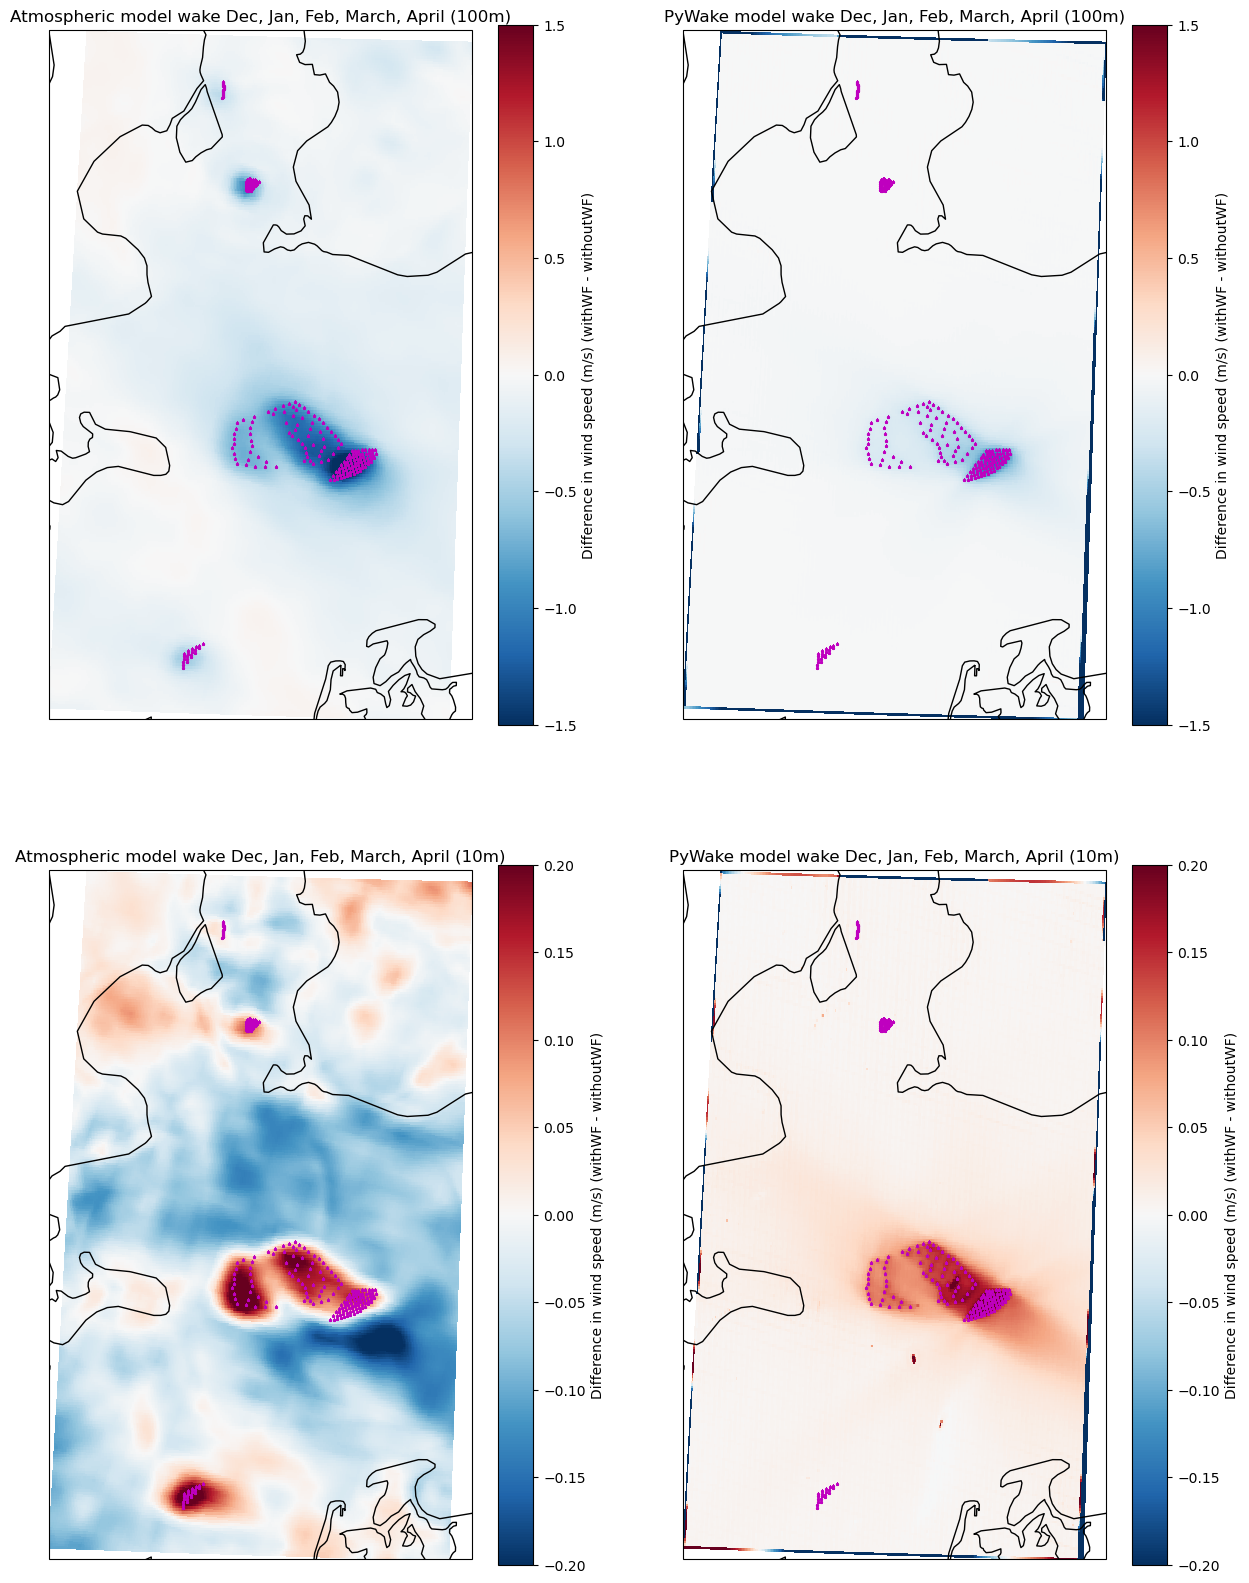

In [37]:
proj1=ccrs.NearsidePerspective(central_longitude=15.5,central_latitude=52,satellite_height=1400E3)
fig,ax=plt.subplots(nrows=2,ncols=2,sharex=True,sharey=True,figsize=(15,20),subplot_kw={'projection':proj1})

mesh1 = ax[0,0].pcolormesh(h_WF.longitude, h_WF.latitude, h_WF['ws'] - h_noWF['ws'], transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-1.5, vmax=1.5)
ax[0,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='m', markersize=2, transform=ccrs.PlateCarree())
ax[0,0].coastlines()

ax[0,0].set_extent([12.2,13.5,54.5,55.8]) # Kriegers Flak
#ax[0,0].set_extent([1.8,3.3,51.7,52.8]) # East Anglia One
#ax[0,0].set_extent([7,8.3,55.2,56.2]) # Horns Rev 3

ax[0,0].set_title('Atmospheric model wake Dec, Jan, Feb, March, April (100m)')
ax[0,0].set_xlabel('Longitude (°)')
ax[0,0].set_ylabel('Latitude (°)')
cbar1 = plt.colorbar(mesh1, ax=ax[0,0])
cbar1.set_label('Difference in wind speed (m/s) (withWF - withoutWF)')

mesh2 = ax[0,1].pcolormesh(py.longitude, py.latitude, py['ws'] - h_noWF['ws'], transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-1.5, vmax=1.5)
ax[0,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='m', markersize=2, transform=ccrs.PlateCarree())
ax[0,1].coastlines()

ax[0,1].set_extent([12.2,13.5,54.5,55.8])
#ax[0,1].set_extent([1.8,3.3,51.7,52.8])
#ax[0,1].set_extent([7,8.3,55.2,56.2])

ax[0,1].set_title('PyWake model wake Dec, Jan, Feb, March, April (100m)')
ax[0,1].set_xlabel('Longitude (°)')
ax[0,1].set_ylabel('Latitude (°)')
cbar2 = plt.colorbar(mesh2, ax=ax[0,1])
cbar2.set_label('Difference in wind speed (m/s) (withWF - withoutWF)')

mesh3 = ax[1,0].pcolormesh(h_WF.longitude, h_WF.latitude, h_WF['10ws'] - h_noWF['10ws'], transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-0.2, vmax=0.2)
ax[1,0].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='m', markersize=2, transform=ccrs.PlateCarree())
ax[1,0].coastlines()

ax[1,0].set_extent([12.2,13.5,54.5,55.8])
#ax[1,0].set_extent([1.8,3.3,51.7,52.8])
#ax[1,0].set_extent([7,8.3,55.2,56.2])

ax[1,0].set_title('Atmospheric model wake Dec, Jan, Feb, March, April (10m)')
ax[1,0].set_xlabel('Longitude (°)')
ax[1,0].set_ylabel('Latitude (°)')
cbar3 = plt.colorbar(mesh3, ax=ax[1,0])
cbar3.set_label('Difference in wind speed (m/s) (withWF - withoutWF)')

mesh4 = ax[1,1].pcolormesh(py.longitude, py.latitude, py['10ws'] - h_noWF['10ws'], transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-0.2, vmax=0.2)
ax[1,1].plot(wt[:,0], wt[:,1], linewidth=0, marker='*', color='m', markersize=2, transform=ccrs.PlateCarree())
ax[1,1].coastlines()

ax[1,1].set_extent([12.2,13.5,54.5,55.8])
#ax[1,1].set_extent([1.8,3.3,51.7,52.8])
#ax[1,1].set_extent([7,8.3,55.2,56.2])

ax[1,1].set_title('PyWake model wake Dec, Jan, Feb, March, April (10m)')
ax[1,1].set_xlabel('Longitude (°)')
ax[1,1].set_ylabel('Latitude (°)')
cbar4 = plt.colorbar(mesh4, ax=ax[1,1])
cbar4.set_label('Difference in wind speed (m/s) (withWF - withoutWF)')